# SEN1721 Travel Behaviour Research

## `In-class assignment 2:`
## `Latent class models`

**Delft University of Technology**<br>
**Q3 2026**<br>
**Instructor:** Sander van Cranenburgh<br>
**TA:**  Gabriel Nova <br>

### `Instructions`

**In-class assignments aim to:**<br>
* Illustrate how models and theory discussed in the classroom work out in practice.
* Help you gather hands-on modelling and data analysis skills.

**In-class assignments are:**<br>
* Learning environments where you work with Python and get support from TA and fellow students.
* Not graded and do not have to be submitted.

### `Use of AI tools`
AI tools, such as ChatGPT and Copilot, are great tools to assist with programming. Moreover, in your later careers, you will work in a world where such tools are widely available. As such, we **encourage** you to use AI tools **effectively**. However, be careful not to overestimate the capacity of AI tools! AI tools cannot replace you: you still have to conceptualise the problem, dissect it and structure it to conduct proper analysis. We recommend being especially **reticent** with using AI tools for the more conceptual and reflection-oriented questions. <br>

**`Learning objectives In-class assignment 2`**

After completing the in-class assignment, you will be able to:
1. Use statistical criteria to determine the number of classes in a Latent Class model
1. Handle local maxima in the estimation of Latent Class models

#### `Import packages`

To begin, we will import all the Python libraries that we will use in this assignment.

In [1]:
# Biogeme
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme.expressions import Beta, PanelLikelihoodTrajectory

# Import custom estimation functions for Biogeme
from bio_estimation_fcns import estimate_LC, print_results

# General python packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path
import seaborn as sns

# Random number generator
from random import random as rand
import random
random.seed(42)

# Pandas setting to show all columns when displaying a pandas dataframe
pd.set_option('display.max_columns', None)

### `1. Load the data set` <br>

In [2]:
# Create that path to the data file
data_path =  Path(f'data/Route_choice_data_cleaned.csv')

# Load the data as a pandas dataframe
df = pd.read_csv(data_path, sep=',')

# Sort the dataframe by ID and Quest to ensure that the choice tasks are in the correct order for each respondent.
# This is important for handling the panel structure of the data later.
df = df.sort_values(by=['ID', 'Quest'], ascending=[True, True])

# Show the first few rows of the data
df.head()

,Survey,ID,Quest,CHOICE,TT1,CONG1,VAR1,TC1,TT2,CONG2,VAR2,TC2,TT3,CONG3,VAR3,TC3,AV1,AV2,AV3,age,edu,edufin,sex,E1,E2,E3,E4,E5,E6,E7
351,2,1325,1,1,45,10,5,12.5,60,25,15,9.0,75,40,25,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
352,2,1325,2,3,75,25,15,12.5,45,40,25,9.0,60,10,5,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
353,2,1325,3,3,60,40,25,12.5,75,10,5,9.0,45,25,15,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
354,2,1325,4,1,60,25,5,9.0,75,40,15,5.5,45,10,25,12.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
355,2,1325,5,2,45,40,15,9.0,60,10,25,5.5,75,25,5,12.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5


**Description of variables**<br>

The data contain (after cleaning) 3,474 stated route choices from 388 respondent. Each alternative is defined by four attributes: TT, CONG, VAR, and TC.
Below is a description of the variables in the data set. For more information about the data, you can have a look at the original paper by [Chorus et al. (2012)](https://link.springer.com/article/10.1007/s11116-012-9444-3). 


| Variable | Description                                                       | Data type                 |
|----------|-------------------------------------------------------------------|---------------------------|
| Survey   | Identifier for the survey                                         | Integer                   |
| ID       | Unique identifier for each respondent                             | Integer                   |
| Quest    | Order of the choice tasks per respondent                          | Integer                   |
| CHOICE   | Chosen alternative                                                | Integer                   |
| TT1      | Travel Time for Alternative 1                                     | Integer                   |
| CONG1    | Percentage of travel time in congestion for Alternative 1         | Integer                   |
| VAR1     | Travel time variability for Alternative 1                         | Integer                   |
| TC1      | Travel Cost for Alternative 1                                     | Float                     |
| TT2      | Travel Time for Alternative 2                                     | Integer                   |
| CONG2    | Percentage of travel time in congestion for Alternative 2         | Integer                   |
| VAR2     | Travel time variability for Alternative 2                         | Integer                   |
| TC2      | Travel Cost for Alternative 2                                     | Float                     |
| TT3      | Travel Time for Alternative 3                                     | Integer                   |
| CONG3    | Percentage of travel time in congestion for Alternative 3         | Integer                   |
| VAR3     | Travel time variability for Alternative 3                         | Integer                   |
| TC3      | Travel Cost for Alternative 3                                     | Float                     |
| AV1      | Availability of Alternative 1 (0: not available, 1: available)    | Integer                   |
| AV2      | Availability of Alternative 2 (0: not available, 1: available)    | Integer                   |
| AV3      | Availability of Alternative 3 (0: not available, 1: available)    | Integer                   |
| age      | Age of the respondent                                             | Integer                   |
| edu      | Educational level                                                 | Integer                   |
| edufin   | Max education level                                               | Integer                   |
| sex      | Gender of the respondent (e.g., male, female)                     | Integer                   |
| E1       | I considered it difficult to make choices across the presented alternatives in this choice experiment | Integer                   |
| E2       | I considered it important to make the ‘right’ choice across the presented alternatives                | Integer                   |
| E3       | When considering a new job or residential location, having a pleasant commute takes a central place in my decision | Integer      |
| E4       | In general, I think making choices is difficult                                                       | Integer                   |
| E5       | When decisions are important I consider making choices difficult                                      | Integer                   |
| E6       | When making choices, I consider the possibility that I will regret my choice in hindsight             | Integer                   |
| E7       | When making choices, I prefer a choice set that is as large as possible                               | Integer                   |

### `2. Creating the Biogeme database and global variables` <br>

**`Biogeme database for panel models`**<br>
To use Biogeme for estimation, we first need to create the data set as a Biogeme database object using `db.Database()`. This object contains the data in a format compatible with the library functions for model estimation in Biogeme.

In [3]:
# We don't need all columns for the this in-class assignment, so we create a new dataframe with only the relevant columns for the estimation of the models. 
# We will use this dataframe to create the Biogeme database.
df_bio = df[['ID', 'CHOICE',  # Respondent information and choice variable
             'TT1', 'CONG1', 'VAR1', 'TC1', # Attributes of alternative 1
             'TT2', 'CONG2', 'VAR2', 'TC2', # Attributes of alternative 2
             'TT3', 'CONG3', 'VAR3', 'TC3', # Attributes of alternative 3
             'AV1', 'AV2','AV3' ]]          # Availability of the alternatives

In [4]:
# Now we create the Biogeme database using the `db.Database` function. 
# This function takes two arguments:
# (1) a name (string) 
# (2) a data set (pandas dataframe)
biodata_panel = db.Database('data_panel', df_bio.copy()) # Creates a biogeme database

**`Panel column`**<br>
In panel data, each individual is identified by a unique identifier. In our case, the panel identifier is `ID`. This variable is essential for Biogeme to correctly handle panel data models. Using the `.panel()` function, we can specify the panel variable.

In [5]:
# We specify that the panel structure is defined by "ID"
biodata_panel.panel("ID")  

**`Global variables`**<br>
Additionally, we need to make the variables in our data set globally available in the environment.<br>

In [6]:
# Create global variables for each column in the dataframe.
for col in biodata_panel.data.columns:
    globals()[col] = biodata_panel.variables[col]
print(f"Global variables are created for:\n{list(biodata_panel.data.columns)}")

Global variables are created for:
['ID', 'CHOICE', 'TT1', 'CONG1', 'VAR1', 'TC1', 'TT2', 'CONG2', 'VAR2', 'TC2', 'TT3', 'CONG3', 'VAR3', 'TC3', 'AV1', 'AV2', 'AV3']


### `3. Determining the optimal number of classes` <br>

Determining the number of classes in a latent class model often is a challenging task. Typically, it involves a **trade-off** between statistical performance (BIC) and behavioural interpretebility.<br><br>
To determine the optimal number of classes, we create a `for loop` to swiftly estimate LC models with an increasing numbers of classes.<br>
In the loop, we store the BIC, LL, and the estimation result object in lists for later analysis.

In [7]:
# Create empty list to store the BIC, LL, and results object
BIC = []
LL = []
lst_LC_results = []

# Set the number of classes to estimate
lst_classes = [2,3,4,5,6]

# Loop over the number of classes to estimate
for n_classes in lst_classes:
    print(f'Estimating LC model with {n_classes} classes ... be patient, this may take a while')

    # Give a name to the model
    model_name = f'LC with {n_classes} classes'

    # Define the model parameters for each class
    B_tt = {}
    B_cong = {}
    B_var = {}
    B_tc = {}

    for k in range(n_classes):
        B_tt[k]    = Beta(f'B_tt_{k}',   0, None, None, 0)
        B_cong[k]  = Beta(f'B_cong_{k}', 0, None, None, 0)
        B_var[k]   = Beta(f'B_var_{k}',  0, None, None, 0)
        B_tc[k]    = Beta(f'B_tc_{k}',   0, None, None, 0)

    # Define the membership model parameters
    delta = {}
    for k in range(n_classes):  
        if k == 0: # The first class (0) is fixed to 0; 
            delta[k] = Beta(f'delta_{k}', 0, None, None, 1)
        else: # We use different random starting values for each class
            delta[k] = Beta(f'delta_{k}', -rand(), None, None, 0)

    # Define the utility functions for each class
    V = [{} for _ in range(n_classes)]  # List of dictionaries for each class

    for k in range(n_classes):
        V[k] = {
            1: B_tt[k] * TT1 + B_cong[k] * CONG1 + B_var[k] * VAR1 + B_tc[k] * TC1,
            2: B_tt[k] * TT2 + B_cong[k] * CONG2 + B_var[k] * VAR2 + B_tc[k] * TC2,
            3: B_tt[k] * TT3 + B_cong[k] * CONG3 + B_var[k] * VAR3 + B_tc[k] * TC3
                }

    # Availability dictionary (same for all classes)
    AV = {1: AV1, 2: AV2, 3: AV3}  

    # Define the membership model value functions for each class
    nu = [delta[k] for k in range(n_classes)]

    # Estimate the LC model
    results_LC = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

    # Store the BIC, LL values, and estimation result object in lists
    BIC.append(results_LC.get_general_statistics()['Bayesian Information Criterion'][0])
    LL.append(results_LC.get_general_statistics()['Final log likelihood'][0])
    lst_LC_results.append(results_LC)

# Create a pandas dataframe with the results (LL and BIC) for each class
df_results = pd.DataFrame({'classes': lst_classes, 'LL':LL,'BIC': BIC}).round(2)

# Show the results
df_results

Estimating LC model with 2 classes ... be patient, this may take a while
Estimating LC model with 3 classes ... be patient, this may take a while
Estimating LC model with 4 classes ... be patient, this may take a while
Estimating LC model with 5 classes ... be patient, this may take a while
Estimating LC model with 6 classes ... be patient, this may take a while


,classes,LL,BIC
0,2,-2413.17,4879.94
1,3,-2362.45,4808.29
2,4,-2337.73,4788.61
3,5,-2319.83,4782.59
4,6,-2309.89,4792.50


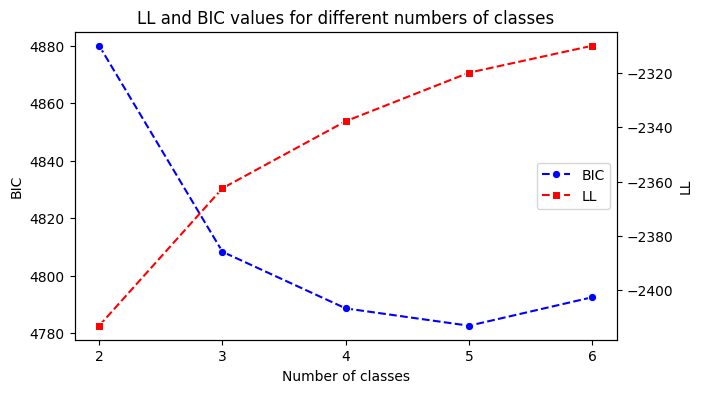

In [8]:
# Plot the BIC values and LL as a function of the number of classes
fig, ax1 = plt.subplots(figsize=(7, 4))

# Left y-axis: BIC
sns.lineplot(x='classes',y='BIC',data=df_results,linestyle='dashed',color='blue',marker='o',label='BIC',legend = False, ax=ax1)
ax1.set_xlabel('Number of classes')
ax1.set_ylabel('BIC')
ax1.set_xticks(df_results['classes'].unique())

# Right y-axis: LL
ax2 = ax1.twinx()
sns.lineplot(x='classes',y='LL',data=df_results,linestyle='dashed',marker='s',color='red',label='LL',legend = False,ax=ax2)
ax2.set_ylabel('LL')

# Combine legend entries manually
lines = ax1.lines + ax2.lines
labels = ['BIC', 'LL']
ax1.legend(lines, labels, loc='center right')

plt.title('LL and BIC values for different numbers of classes')
plt.show()

**Interpretation of the estimation results**

        --> The blue line in the plot shows that the statistically best model (i.e. with the minimum BIC) is the model with 5 classes.
        --> The red line in the plot shows that increasing the number of classes leads to an increase in the LL, which is, indeed, expected. 

In [9]:
# Identify the index (row) with the minimum BIC value (i.e. the best statistical model)
idx = df_results.idxmin()['BIC'] 

# Print the results of the statistically best model
print_results(lst_LC_results[idx])



Results for model LC with 5 classes
Nbr of parameters             :       24
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2319.83
Likelihood ratio test (null)  :  2993.51
Rho square (null)             :     0.39
Rho bar square (null)         :     0.39
Akaike Information Criterion  :  4687.65
Bayesian Information Criterion:  4782.59

Estimates of the parameters:
            Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0 -0.0094        0.0093        -1.01          0.31
B_cong_1 -0.0110        0.0041        -2.71          0.01
B_cong_2 -0.1269        0.0202        -6.29          0.00
B_cong_3 -0.0423        0.0042       -10.15          0.00
B_cong_4 -0.0314        0.0232        -1.35          0.18
B_tc_0   -0.1444        0.0665        -2.17          0.03
B_tc_1   -0.0450        0.0282        -1.60          0.11
B_tc_2   -0.1643

**Interpretation of the estimation results**

        --> Interpreting the parameters of the 5-class model is challenging. The classes are not well-separated. Moreover, the many parameters of the model are not statistically significant.

        --> As such, arguably, the 3-class model is the best model, considering a trade-off between behavioural interpretability and statistical performance. This model is more interpretable than the 5-class model. The classes are better separated, and most of the parameters are statistically significant. Moroever, going from 3 to 5 classes does not improve the BIC much.

### `Exercise 1:  Giving a meaningful names to the classes `<br>

Typically, after estimating a latent class model, we would like to give meaningful names to the classes. This can be done by looking at the parameter estimates of the model and by looking at the willingness-to-pay estimates for each class. For the **3-class solution**:<br>
`A.` Identify the row number of the 3-class solution in `df_results`, and print the results for the 3-class solution by accessing the `lst_LC_results` list (hint: you can use print_results(lst_LC_results[row_number])) <br>
`B.` Compute the Value-of-Travel-Time estimates for each class, using $VTT_{s} = 60\cdot\frac{\beta^{tt}_{s}}{\beta^{cost}_{s}}$ <br>
`C.` Compute the willingness-to-pay to reduce the amount of congestion by 10% for each class, using $WTP_{s} = 10\cdot\frac{\beta^{cong}_{s}}{\beta^{cost}_{s}}$ <br>
`D.`  Based on the VTT and willingness-to-pay estimates, give meaningful names to the classes.<br>
`E.`  Looking at the membership constants (i.e. the deltas), which class is the largest class?

In [10]:
# A

# Row number where the number of classes is 3
row_number = df_results.index[df_results['classes'] == 3][0]
print(f'The 3-class solution is in row: {row_number}\n')

# Print the results for the 3-class solution
print_results(lst_LC_results[row_number])

The 3-class solution is in row: 1



Results for model LC with 3 classes
Nbr of parameters             :       14
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2362.45
Likelihood ratio test (null)  :  2908.25
Rho square (null)             :     0.38
Rho bar square (null)         :     0.38
Akaike Information Criterion  :  4752.91
Bayesian Information Criterion:  4808.29

Estimates of the parameters:
            Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0 -0.0087        0.0051        -1.70          0.09
B_cong_1 -0.0428        0.0047        -9.08          0.00
B_cong_2 -0.0376        0.0068        -5.55          0.00
B_tc_0   -0.1161        0.0259        -4.48          0.00
B_tc_1   -0.3572        0.0330       -10.83          0.00
B_tc_2   -0.0731        0.0208        -3.51          0.00
B_tt_0   -0.1618        0.0155       -1

In [11]:
# B and C
n_classes = 3
VTT = []
WTP = []
for k in range(n_classes):
    # Compute the Value-of-Travel-Time (VTT) and Willingness-to-Pay (WTP) for each class
    VTT = 60*(lst_LC_results[1].get_beta_values()[f'B_tt_{k}']/lst_LC_results[1].get_beta_values()[f'B_tc_{k}'])
    WTP = 10*(lst_LC_results[1].get_beta_values()[f'B_cong_{k}']/lst_LC_results[1].get_beta_values()[f'B_tc_{k}'])

    # Print the results for each class
    print(f'Class {k}:   VTT = {VTT:6.2f} €/hr\tWTP to reduce congestion by 10% = €{WTP:.2f}')


Class 0:   VTT =  83.63 €/hr	WTP to reduce congestion by 10% = €0.75
Class 1:   VTT =  12.24 €/hr	WTP to reduce congestion by 10% = €1.20
Class 2:   VTT =   8.65 €/hr	WTP to reduce congestion by 10% = €5.14


In [12]:
# D
# Class 0 "Time-sensitive commuters". This class has the highest VTT but the lowest willingness-to-pay to reduce congestion (in fact, it is not significantly different from 0). 
# Class 1 "Moderately time-sensitive and congestion-sensitive commuters". This class has a moderately high VTT, and cares about congestion. 
# Class 2 "Congestion-sensitive commuters". This class has the lowest VTT, but the highest willingness-to-pay to reduce congestion.

# E The largest class is the class with the highest membership constant (delta). In this case, it is class 1. But note that the p value is larger than 0.05. This means that class 1 is not significantly larger than class 0 (whihc was fixed to zero).

### `4. Exploring robustness and convergence stability` <br>
The log-likelihood function is a mathematical function that represents the log of the probability of observing the given data under a specific statistical model, as a function of the model parameters. It is used to estimate the parameters of the choice model that are most likely to have produced the observed data.
<br><br>
However, when estimation a choice model, the estimation algorithm may get stuck in **local** maxima. This happens if the likelihood function of the model is not **globally concave**. Local maxima are solutions where the function reaches a high value but not the highest possible. In contrast, a global maximum refers to the highest value of the function across its entire domain. In case, an optimisation algorithm gets stuck in a local solution, it does not recover the true maximum likelihood estimates. Such estimates are thus biased are should never be used for policy making. Hence, choice modellers should be aware of the possibility that optimisation algorithms can get stuck in local solutions. Unfortunately, getting stuck in local solutions is a common issue with the estimation of LC choice models. 
<br><br>
One strategy to deal with local maxima is to try different starting points. Below, we estimate the 2-class LC model using 20 different starting points. Specifically, we use a random starting point between -1 and 0 for all parameters, using the rand() function: (using -rand()). Furthermore, we set the seed number for each ran to a different value, to ensure that the starting points are different (and reproducible). One can never be sure that the estimated parameters are the global maximum, but by trying different starting points, one can increase the likelihood of finding the global maximum.

In [13]:
# Create empty list to store the LL, run, and results object
LL = []
run = []
lst_LC_results_runs = []

# Set the number of runs
N_runs = 25
print(f"Starting estimation of {N_runs} runs ...")
for i in range(1,N_runs+1):
    
    # Set the seed for the random number generator
    random.seed(i)

    # Give a name to the model    
    model_name = 'LC with 2 classes, run ' + str(i)

    # Define the model parameters for class 0
    B_tt_0    = Beta('B_tt_0',  -rand(), None, None, 0)
    B_cong_0  = Beta('B_cong_0',-rand(), None, None, 0)
    B_var_0   = Beta('B_var_0', -rand(), None, None, 0)
    B_tc_0    = Beta('B_tc_0',  -rand(), None, None, 0)

    # Define the utility functions for class 1
    B_tt_1    = Beta('B_tt_1',  -rand(), None, None, 0)
    B_cong_1  = Beta('B_cong_1',-rand(), None, None, 0)
    B_var_1   = Beta('B_var_1', -rand(), None, None, 0)
    B_tc_1    = Beta('B_tc_1',  -rand(), None, None, 0)

    # Define the membership model parameters
    delta_0 = Beta('delta_0',  0,       None, None, 1)
    delta_1 = Beta('delta_1',  -rand(), None, None, 0)
    
    # Define the utility functions for class 0
    V1_0 = B_tt_0 * TT1 + B_cong_0 * CONG1 + B_var_0 * VAR1 + B_tc_0 * TC1
    V2_0 = B_tt_0 * TT2 + B_cong_0 * CONG2 + B_var_0 * VAR2 + B_tc_0 * TC2
    V3_0 = B_tt_0 * TT3 + B_cong_0 * CONG3 + B_var_0 * VAR3 + B_tc_0 * TC3

    # Define the utility functions for class 1
    V1_1 = B_tt_1 * TT1 + B_cong_1 * CONG1 + B_var_1 * VAR1 + B_tc_1 * TC1
    V2_1 = B_tt_1 * TT2 + B_cong_1 * CONG2 + B_var_1 * VAR2 + B_tc_1 * TC2
    V3_1 = B_tt_1 * TT3 + B_cong_1 * CONG3 + B_var_1 * VAR3 + B_tc_1 * TC3

    # Create a dictionary associating utility functions with the numbering of alternatives in the "choice" column
    V_0 = {1: V1_0, 2: V2_0, 3: V3_0}
    V_1 = {1: V1_1, 2: V2_1, 3: V3_1}

    # Put the dictionaries of utility functions in a list
    V = [V_0, V_1]

    # Create a dictionary to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
    AV = {1: AV1, 2: AV2, 3: AV3} 

    # Define the membership model value functions for each class
    nu_0 = delta_0 # Note: one class needs to be fixed to 0. delta_0 is fixed to 0
    nu_1 = delta_1

    # Put membership functions in a list
    nu = [nu_0, nu_1]

    # Estimate the LC model
    results_LC = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

    # Get the log-likelihood value  
    ll_final = results_LC.get_general_statistics()['Final log likelihood'][0]

    # Store the BIC and LL values in lists
    LL.append(ll_final)
    run.append(i)
    lst_LC_results_runs.append(results_LC)
    
    # Print the progress
    print(f'Run {i:2d}/{N_runs}\t LL_init = {results_LC.get_general_statistics()["Init log likelihood"][0]:.2f} --> LL_final = {np.round(ll_final,2)}')

df_runs = pd.DataFrame({'run': run, 'LL':LL}).round(3)

Starting estimation of 25 runs ...
Run  1/25	 LL_init = -12156.82 --> LL_final = -2555.57
Run  2/25	 LL_init = -20392.79 --> LL_final = -2425.7
Run  3/25	 LL_init = -9267.88 --> LL_final = -2413.17
Run  4/25	 LL_init = -7608.89 --> LL_final = -2413.17
Run  5/25	 LL_init = -18487.93 --> LL_final = -2413.17
Run  6/25	 LL_init = -17399.92 --> LL_final = -2425.7
Run  7/25	 LL_init = -10225.36 --> LL_final = -2413.17
Run  8/25	 LL_init = -21312.53 --> LL_final = -2574.5
Run  9/25	 LL_init = -11583.94 --> LL_final = -2467.15
Run 10/25	 LL_init = -12534.27 --> LL_final = -2558.12
Run 11/25	 LL_init = -14505.22 --> LL_final = -2467.15
Run 12/25	 LL_init = -11354.41 --> LL_final = -2425.7
Run 13/25	 LL_init = -6739.53 --> LL_final = -2556.86
Run 14/25	 LL_init = -11427.56 --> LL_final = -2558.13
Run 15/25	 LL_init = -21068.87 --> LL_final = -2413.17
Run 16/25	 LL_init = -12449.82 --> LL_final = -2413.17
Run 17/25	 LL_init = -18068.54 --> LL_final = -2413.17
Run 18/25	 LL_init = -12789.89 --> LL

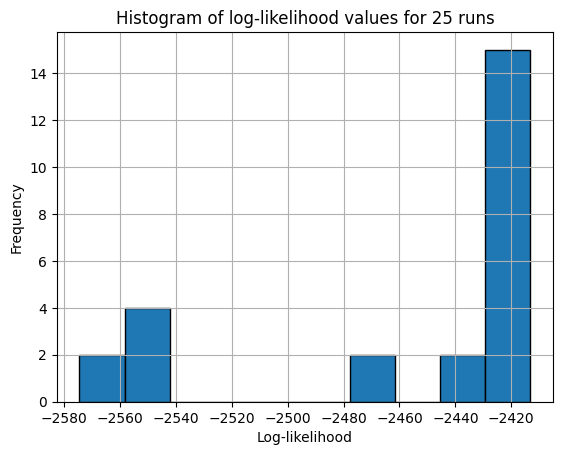

In [14]:
# Plot the histogram of the log-likelihood values
df_runs.hist(column='LL', bins=10, edgecolor='black', linewidth=1)
plt.xlabel('Log-likelihood')
plt.ylabel('Frequency')
plt.title(f'Histogram of log-likelihood values for {len(df_runs)} runs')
plt.show()

**Interpretation**<br>

        --> The histogram shows that a substantial share of the estimation end up in a local maxima. The best-known solution (and probably the global maximum) is the model with LL = -2413.167
        
        --> The implication of the existance of local maxima is that we need to estimate the model multiple times with different starting points to increase the likelihood of finding the global maximum.

        --> Using "good" starting points is also helpful to avoid local maxima. In this case, we used negative starting points because we expect all marginal utilities (betas) to be negative. However, the starting points were probably too a bit large (-1,0) as the betas in this model were found to be considerably smaller.

### `Exercise 2:  Investigating parameter stability `<br>

`A.` Investigate the parameter stability. To do so, <br>
1. Put all the results in a dataframe, using `df_beta_values = pd.DataFrame([lst_LC_results_runs[i].get_beta_values() for i in range(N_runs)])` <br>
2. Show the results in a boxplot using `sns.boxplot(data=df_beta_values.iloc[:,:-1], showfliers=False)`. Try turning on and off the showfliers option to see the full distribution of the estimates. Are the estimates stable across the different runs? <br>

`B.` Investigate the parameter stability of the "good runs". To do so,  <br>
1. Add the Log-likelihoods to the dataframe, using `df_beta_values_LL = pd.concat((df_runs,df_beta_values), axis = 1)`<br>
2. Keep only the results with the LL of the best known solution (with a small margin), using `df_beta_values_opt = df_beta_values_LL[df_beta_values_LL['LL'] > -2414]`<br>
3. Carefully inspect df_beta_values_opt. Do you see a symmetry in the estimations? Explain why this symmetry occurs. <br>
4. Are the estimates stable across these runs? <br>


In [15]:
# A) Investigate the parameter stability
# 1. Put all the results in a dataframe
df_beta_values = pd.DataFrame([lst_LC_results_runs[i].get_beta_values() for i in range(N_runs)])
df_beta_values

,B_cong_0,B_cong_1,B_tc_0,B_tc_1,B_tt_0,B_tt_1,B_var_0,B_var_1,delta_1
0,-0.850073,-0.025378,-0.089342,-0.181534,-7.942946e-09,-0.069576,-0.598262,-0.031815,3.632948
1,-0.035284,-0.005331,-0.203932,-0.108577,-4.990020e-02,-0.731552,-0.027131,-0.501787,-1.177286
2,-0.008312,-0.039175,-0.128850,-0.216597,-1.689914e-01,-0.043874,-0.081086,-0.026342,0.716962
3,-0.039167,-0.008303,-0.216568,-0.128846,-4.388468e-02,-0.169152,-0.026345,-0.081197,-0.717741
4,-0.039167,-0.008303,-0.216569,-0.128846,-4.388457e-02,-0.169151,-0.026345,-0.081197,-0.717713
5,-0.005332,-0.035285,-0.108633,-0.203984,-1.299821e+00,-0.049901,-0.928003,-0.027132,1.175720
6,-0.039172,-0.008295,-0.216586,-0.128899,-4.387627e-02,-0.169066,-0.026343,-0.081143,-0.717180
7,0.306180,-0.027646,-1.599705,-0.174711,9.211798e-01,-0.067689,-0.024720,-0.032255,5.698053
8,-0.033512,0.352703,-0.194367,-0.166072,-5.628740e-02,-0.604849,-0.035275,-0.089984,-1.774543
9,-0.026045,-3.081623,-0.179044,-0.050151,-6.868272e-02,0.210697,-0.032684,2.184573,-4.137141


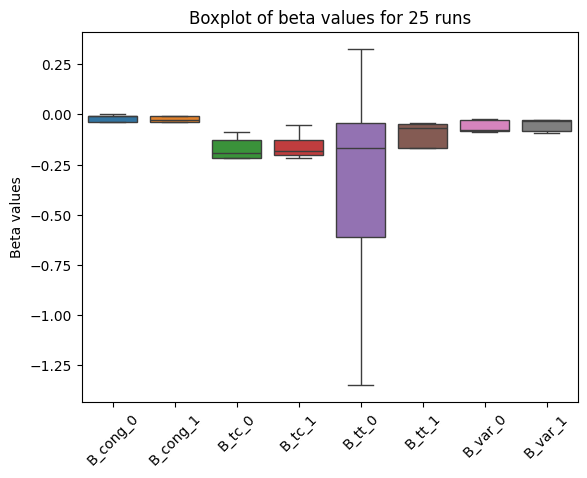

In [16]:
# A) Investigate the parameter stability
# 2. Show the results in a boxplot
sns.boxplot(data=df_beta_values.iloc[:,:-1], showfliers=False)
plt.xticks(rotation=45)
plt.ylabel('Beta values')
plt.title(f'Boxplot of beta values for {N_runs} runs')
plt.show()

In [17]:
# B) Investigate the parameter stability of the "good runs"
# 1. Add the Log-likelihoods to the dataframe
df_beta_values_LL = pd.concat((df_runs,df_beta_values), axis = 1)
df_beta_values_LL

,run,LL,B_cong_0,B_cong_1,B_tc_0,B_tc_1,B_tt_0,B_tt_1,B_var_0,B_var_1,delta_1
0,1,-2555.575,-0.850073,-0.025378,-0.089342,-0.181534,-7.942946e-09,-0.069576,-0.598262,-0.031815,3.632948
1,2,-2425.704,-0.035284,-0.005331,-0.203932,-0.108577,-4.990020e-02,-0.731552,-0.027131,-0.501787,-1.177286
2,3,-2413.167,-0.008312,-0.039175,-0.128850,-0.216597,-1.689914e-01,-0.043874,-0.081086,-0.026342,0.716962
3,4,-2413.167,-0.039167,-0.008303,-0.216568,-0.128846,-4.388468e-02,-0.169152,-0.026345,-0.081197,-0.717741
4,5,-2413.167,-0.039167,-0.008303,-0.216569,-0.128846,-4.388457e-02,-0.169151,-0.026345,-0.081197,-0.717713
5,6,-2425.704,-0.005332,-0.035285,-0.108633,-0.203984,-1.299821e+00,-0.049901,-0.928003,-0.027132,1.175720
6,7,-2413.167,-0.039172,-0.008295,-0.216586,-0.128899,-4.387627e-02,-0.169066,-0.026343,-0.081143,-0.717180
7,8,-2574.499,0.306180,-0.027646,-1.599705,-0.174711,9.211798e-01,-0.067689,-0.024720,-0.032255,5.698053
8,9,-2467.146,-0.033512,0.352703,-0.194367,-0.166072,-5.628740e-02,-0.604849,-0.035275,-0.089984,-1.774543
9,10,-2558.124,-0.026045,-3.081623,-0.179044,-0.050151,-6.868272e-02,0.210697,-0.032684,2.184573,-4.137141


In [18]:
# B) Investigate the parameter stability of the "good runs"
# 2. Keep only the results with the LL of the best known solution
df_beta_values_opt = df_beta_values_LL[df_beta_values_LL['LL'] > -2414]
df_beta_values_opt

,run,LL,B_cong_0,B_cong_1,B_tc_0,B_tc_1,B_tt_0,B_tt_1,B_var_0,B_var_1,delta_1
2,3,-2413.167,-0.008312,-0.039175,-0.128850,-0.216597,-0.168991,-0.043874,-0.081086,-0.026342,0.716962
3,4,-2413.167,-0.039167,-0.008303,-0.216568,-0.128846,-0.043885,-0.169152,-0.026345,-0.081197,-0.717741
4,5,-2413.167,-0.039167,-0.008303,-0.216569,-0.128846,-0.043885,-0.169151,-0.026345,-0.081197,-0.717713
6,7,-2413.167,-0.039172,-0.008295,-0.216586,-0.128899,-0.043876,-0.169066,-0.026343,-0.081143,-0.717180
14,15,-2413.167,-0.039168,-0.008304,-0.216571,-0.128837,-0.043884,-0.169147,-0.026345,-0.081196,-0.717668
15,16,-2413.167,-0.008305,-0.039167,-0.128828,-0.216570,-0.169138,-0.043884,-0.081190,-0.026345,0.717686
16,17,-2413.167,-0.039171,-0.008304,-0.216578,-0.128680,-0.043878,-0.169020,-0.026343,-0.081139,-0.717196
17,18,-2413.167,-0.039172,-0.008306,-0.216585,-0.128797,-0.043878,-0.169052,-0.026343,-0.081134,-0.717243
18,19,-2413.167,-0.008317,-0.039175,-0.128709,-0.216595,-0.168967,-0.043873,-0.081088,-0.026342,0.716913
20,21,-2413.167,-0.008305,-0.039167,-0.128807,-0.216570,-0.169142,-0.043884,-0.081196,-0.026345,0.717664


In [19]:
# B) Investigate the parameter stability of the "good runs"
# 3.
# We observe that the estimates are fully symmetric across the classes. This is expected since the classes are randomly assigned.
# Apart from the symmetry, the estimates are all the same. This implies that the the results are stable across the runs.

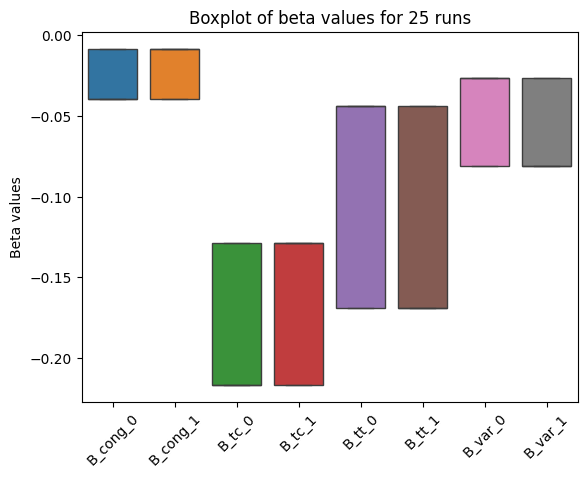

In [20]:
sns.boxplot(data=df_beta_values_opt.iloc[:,2:-1], showfliers=False)
plt.xticks(rotation=45)
plt.ylabel('Beta values')
plt.title(f'Boxplot of beta values for {N_runs} runs')
plt.show()